In [1]:
import numpy, pandas, matplotlib.pyplot, seaborn, sklearn.linear_model, sklearn.model_selection

In [2]:
dataframe = pandas.read_csv("Prices/costinflation-ssd-vs-hdd-prices-2026-07-21-to-2026-08-18.csv", sep=",")
dataframe

,series_id,series_title,canonical_url,geography_type,geography_id,geography_label,observed_date,product_name,quantity_value,quantity_unit,quantity_name,price_amount,currency_code,normalized_price_amount,normalized_quantity_value,normalized_quantity_unit
0,internal_hdd,Internal Hard Drives (HDDs),https://costinflation.com/indices/internal-har...,postal_code,11385,"New York, NY - Ridgewood/Glendale",2026-07-21,"Dell 1TB 7.2K RPM SAS 12Gb/s 2.5"" HDD for Dell...",1.0,terabytes,1 terabytes,69.00,USD,69.000000,1.0,terabytes
1,internal_hdd,Internal Hard Drives (HDDs),https://costinflation.com/indices/internal-har...,postal_code,11385,"New York, NY - Ridgewood/Glendale",2026-07-21,MaxDigitalData 6TB 7200RPM 128MB Cache SATA 6....,6.0,terabytes,6 terabytes,188.99,USD,31.498333,1.0,terabytes
2,internal_hdd,Internal Hard Drives (HDDs),https://costinflation.com/indices/internal-har...,postal_code,11385,"New York, NY - Ridgewood/Glendale",2026-07-21,SEAGATE ST4000VX007 Skyhawk 4TB Surveillance H...,4.0,terabytes,4 terabytes,268.95,USD,67.237500,1.0,terabytes
3,internal_hdd,Internal Hard Drives (HDDs),https://costinflation.com/indices/internal-har...,postal_code,11385,"New York, NY - Ridgewood/Glendale",2026-07-21,Seagate Bare Drives BarraCuda 1TB Internal Har...,1.0,terabytes,1 terabytes,89.99,USD,89.990000,1.0,terabytes
4,internal_hdd,Internal Hard Drives (HDDs),https://costinflation.com/indices/internal-har...,postal_code,11385,"New York, NY - Ridgewood/Glendale",2026-07-21,Seagate BarraCuda 1TB Internal Hard Drive HDD ...,1.0,terabytes,1 terabytes,99.99,USD,99.990000,1.0,terabytes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121982,nvme_ssd,NVMe SSDs,https://costinflation.com/indices/nvme-ssd-pri...,postal_code,98118,"Seattle, WA - Rainier Valley",2026-08-18,"fanxiang S880 NVMe SSD 4TB, PCIe 4.0 M.2 2280 ...",4.0,terabytes,4 terabytes,499.99,USD,124.997500,1.0,terabytes
121983,nvme_ssd,NVMe SSDs,https://costinflation.com/indices/nvme-ssd-pri...,postal_code,98118,"Seattle, WA - Rainier Valley",2026-08-18,ist computers BG6 512GB M.2 2230 PCIe Gen4x4 N...,512.0,gigabytes,512 gigabytes,129.98,USD,253.867188,1.0,terabytes
121984,nvme_ssd,NVMe SSDs,https://costinflation.com/indices/nvme-ssd-pri...,postal_code,98118,"Seattle, WA - Rainier Valley",2026-08-18,msi Gaming SPATIUM M480 PRO PCIe 4.0 NVMe M.2 ...,1.0,terabytes,1 terabytes,204.99,USD,204.990000,1.0,terabytes
121985,nvme_ssd,NVMe SSDs,https://costinflation.com/indices/nvme-ssd-pri...,postal_code,98118,"Seattle, WA - Rainier Valley",2026-08-18,msi SPATIUM M461 PCIe 4.0 NVMe M.2 2TB Interna...,2.0,terabytes,2 terabytes,319.00,USD,159.500000,1.0,terabytes


In [3]:
dataframe.isna().sum()

series_id                       0
series_title                    0
canonical_url                   0
geography_type                  0
geography_id                    0
geography_label                 0
observed_date                   0
product_name                    0
quantity_value                  0
quantity_unit                   0
quantity_name                   0
price_amount                    0
currency_code                   0
normalized_price_amount      4467
normalized_quantity_value       0
normalized_quantity_unit        0
dtype: int64

In [4]:
dataframe = dataframe.dropna(subset="normalized_price_amount")
dataframe.isna().sum()

series_id                    0
series_title                 0
canonical_url                0
geography_type               0
geography_id                 0
geography_label              0
observed_date                0
product_name                 0
quantity_value               0
quantity_unit                0
quantity_name                0
price_amount                 0
currency_code                0
normalized_price_amount      0
normalized_quantity_value    0
normalized_quantity_unit     0
dtype: int64

In [5]:
dataframe.dtypes

series_id                        str
series_title                     str
canonical_url                    str
geography_type                   str
geography_id                   int64
geography_label                  str
observed_date                    str
product_name                     str
quantity_value               float64
quantity_unit                    str
quantity_name                    str
price_amount                 float64
currency_code                    str
normalized_price_amount      float64
normalized_quantity_value    float64
normalized_quantity_unit         str
dtype: object

In [6]:
dataframe.observed_date = pandas.to_datetime(dataframe.observed_date)
dataframe.dtypes

series_id                               str
series_title                            str
canonical_url                           str
geography_type                          str
geography_id                          int64
geography_label                         str
observed_date                datetime64[us]
product_name                            str
quantity_value                      float64
quantity_unit                           str
quantity_name                           str
price_amount                        float64
currency_code                           str
normalized_price_amount             float64
normalized_quantity_value           float64
normalized_quantity_unit                str
dtype: object

In [7]:
daily_average = dataframe.groupby("observed_date")["normalized_price_amount"].mean().reset_index()
daily_average

,observed_date,normalized_price_amount
0,2026-07-21,201.259216
1,2026-07-22,207.351811
2,2026-07-23,203.207993
3,2026-07-24,201.371208
4,2026-07-25,205.518338
5,2026-07-26,204.705633
6,2026-07-27,204.177112
7,2026-07-28,199.609829
8,2026-07-29,201.410937
9,2026-07-30,201.034977


In [8]:
daily_average['days_since_start'] = (daily_average['observed_date'] - daily_average['observed_date'].min()).dt.days
daily_average

,observed_date,normalized_price_amount,days_since_start
0,2026-07-21,201.259216,0
1,2026-07-22,207.351811,1
2,2026-07-23,203.207993,2
3,2026-07-24,201.371208,3
4,2026-07-25,205.518338,4
5,2026-07-26,204.705633,5
6,2026-07-27,204.177112,6
7,2026-07-28,199.609829,7
8,2026-07-29,201.410937,8
9,2026-07-30,201.034977,9


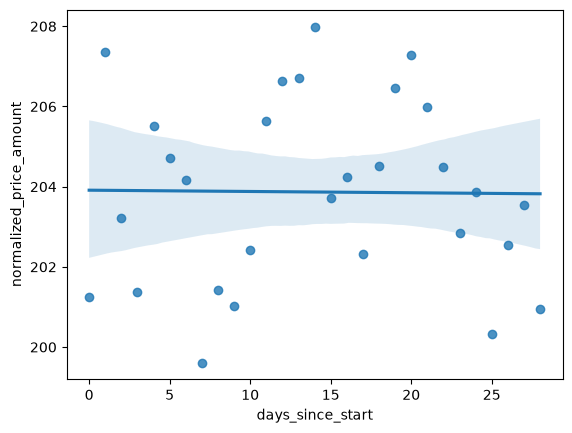

In [9]:
seaborn.regplot(data=daily_average, x='days_since_start', y='normalized_price_amount')
matplotlib.pyplot.show()

In [10]:
X = daily_average[["days_since_start"]]
Y = daily_average[["normalized_price_amount"]]

In [11]:
X_train, x_test, Y_train, y_test = sklearn.model_selection.train_test_split(X, Y, test_size=0.25)

In [12]:
regression_model = sklearn.linear_model.LinearRegression()
regression_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
regression_model.fit(X, Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[-0.]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['days_since_start']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[203.91]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [14]:
regression_model.score(X, Y)

0.0001386658993601797

In [15]:
regression_model.predict([[12]]).tolist()[0][0]

d:\program files\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


203.87351843054455